In [1]:
import pandas as pd
import numpy as np
import time


from selenium.webdriver.common.keys import Keys

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

import requests

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
mens_list_url = "https://pricespy.co.uk/c/perfume?98221=31505"

In [ ]:
#Using selenium to find the name and price of every mens perfume from pricespy website and appending them to lists

driver = webdriver.Chrome()
driver.get(mens_list_url)


time.sleep(2)
iframe = driver.find_element(By.XPATH, value='//*[@id="sp_message_iframe_1316049"]')
driver.switch_to.frame(iframe)
time.sleep(2)

driver.find_element(By.XPATH, value='//*[@id="notice"]/div[2]/button[1]').click()

driver.switch_to.default_content()

names_final = []
prices_final = []

for num in range(110):
    time.sleep(2)
    articles = driver.find_elements(By.TAG_NAME, 'article')
    n = []
    p = []
    for article in articles:
        try:
            n.append(article.find_element(By.CLASS_NAME, "Text--q06h0j.hmEZMX.titlesmalltext").text)
        except:
            n.append("error")
        try:
            p.append(article.find_element(By.CLASS_NAME, "Text--q06h0j.igDZdP").text)
        except:
            p.append("error")
    n.append(n[:-8])
    p.append(p[:-8])
    names_final.append(n)
    prices_final.append(p)
    driver.find_element(By.CLASS_NAME, 'StyledIcon--jy2io5.kQRcg.iconchevronright').click()

In [73]:
#converting lists from selenium names_final output into individual values 
names = []
for list in names_final:
    for name in list:
        names.append(name)

In [74]:
#converting lists from selenium prices_final output into individual values 
prices = []
for list in prices_final:
    for price in list:
        prices.append(price)

In [76]:
len(names)

5821

In [65]:
names = names[:4755]

In [77]:
perfumes = pd.DataFrame({"name" : names, "price" : prices})

In [84]:
perfumes[4500:]

,name,price
4500,Dior Fahrenheit edt 100ml,£43.00
4501,Prada Paradoxe Edp 30ml Refill 100ml,£53.00
4502,Giorgio Armani Stronger With You Intensely edp...,£45.00
4503,Lancome La Vie Est Belle edp 100ml,£38.00
4504,"[Tabac Original edt 30ml, Swiss Arabian Edge I...","[£12.72, £22.95, £29.99, £39.95, £13.60, £63.2..."
...,...,...
5816,Dior Fahrenheit edt 100ml,£43.00
5817,Prada Paradoxe Edp 30ml Refill 100ml,£53.00
5818,Giorgio Armani Stronger With You Intensely edp...,£45.00
5819,Lancome La Vie Est Belle edp 100ml,£38.00


In [85]:
perfumes.to_csv("perfumes_unpro.csv")

In [4]:
perf = pd.read_csv("perfumes_unpro.csv")

In [56]:
perf["name"].value_counts()

name
Jean Paul Gaultier Le Male Elixir Parfum 125ml                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [54]:
perf["price"].value_counts()

price
£36.00                                                                                                                                                                                                                                                                                                                                                                 223
error                                                                                                                                                                                                                                                                                                                                                                  121
£20.00                                                                                                                                                                                                                                                                      

In [50]:
#Checking values within eronious list for duplication
perf[perf["name"] == "Giorgio Armani Acqua Di Gio Essenza Pour Homme edt 100ml"]

,Unnamed: 0,name,price
5809,5809,Giorgio Armani Acqua Di Gio Essenza Pour Homme...,£98.55


In [57]:
#Erronious lists contain duplicates of individual values

drop = perf["price"] == "['£29.00', '£19.99', '£31.07', '£35.00', '£31.76', '£199.49', '£342.47', '£12.65', '£53.09', '£45.99', '£90.00', '£18.27', '£40.03', '£28.58', '£106.05', '£146.06', '£108.04', 'error', '£39.00', '£50.00', '£11.49', '£47.18', 'error', '£39.99', '£89.24', '£19.00', '£48.37', '£41.79', '£29.30', '£75.30', '£15.99', '£10.32', '£98.55', '£128.47', '£172.46']" 

In [60]:
#decided to drop values contianing lists
perf = perf[~drop]

In [61]:
perf["name"].value_counts()

name
Jean Paul Gaultier Le Male Elixir Parfum 125ml         111
Creed Aventus edp 100ml                                111
Giorgio Armani Stronger With You Intensely edp 30ml    111
Dior Fahrenheit edt 100ml                              111
Lancome La Vie Est Belle edp 100ml                     110
                                                      ... 
Daniel Hechter Coton Chic edt 100ml                      1
Fomo A Fraghead's Asylum Perfume Extract 100ml           1
Prada Luna Rossa edt 50ml                                1
Giorgio Armani Code Pour Homme edp 75ml                  1
True Religion for Him edt 50ml                           1
Name: count, Length: 4885, dtype: int64

In [68]:
perf[perf["price"] == "error"]

,Unnamed: 0,name,price
442,442,Kenzo Homme Santal Marin edt 110ml,error
1193,1193,Atkinsons English Lavender edt 90ml,error
1685,1685,Loewe Fashion Esencia Homme edp 150ml,error
1963,1963,Thierry Mugler A*Men Pure Havane edt 100ml,error
1967,1967,Atkinsons English Lavender edt 150ml,error
...,...,...,...
5658,5658,Jacadi Jeune Homme edt 50ml,error
5708,5708,Jacadi Jeune Homme edt 100ml,error
5727,5727,Loewe Fashion 7 Cobalt edp 150ml,error
5794,5794,IKKS Young Man edt 100ml,error


In [72]:
#Dropping values of price that match "error"
drop2 = perf["price"] == "error"

In [73]:
perf = perf[~drop2]

In [75]:
perf.value_counts()

Unnamed: 0  name                                                 price  
0           Jean Paul Gaultier Le Male Elixir Parfum 125ml       £35.64     1
3858        Prada Amber Pour Homme Intense edp 100ml             £215.95    1
3878        Gant 1949 EdT 100ml                                  £63.20     1
3877        Dolce & Gabbana The One Mysterious Night edp 150ml   £199.95    1
3876        Ajmal Sea Cruiser edt 50ml                           £12.07     1
                                                                           ..
1900        Rasasi Rumz Al Zebra Pour Elle edp 50ml              £20.00     1
1899        Jean Paul Gaultier Le Male Elixir Parfum 125ml       £36.00     1
1898        Tom Tailor Adventurous edt for Men 50ml              £25.10     1
1897        Carolina Herrera Bad Boy Elixir pour homme edp 50ml  £68.10     1
5819        Lancome La Vie Est Belle edp 100ml                   £38.00     1
Name: count, Length: 5699, dtype: int64

In [76]:
perf

,Unnamed: 0,name,price
0,0,Jean Paul Gaultier Le Male Elixir Parfum 125ml,£35.64
1,1,Creed Aventus edp 100ml,£199.99
2,2,Afnan Supremacy Collector's Edition edp 100ml,£32.69
3,3,Rasasi Hawas Ice For Him edp 100ml,£20.09
4,4,Jean Paul Gaultier Le Beau Le Parfum 125ml,£38.02
...,...,...,...
5815,5815,Viktor & Rolf Flowerbomb edp 100ml,£36.00
5816,5816,Dior Fahrenheit edt 100ml,£43.00
5817,5817,Prada Paradoxe Edp 30ml Refill 100ml,£53.00
5818,5818,Giorgio Armani Stronger With You Intensely edp...,£45.00


In [ ]:
#Searching for erronious lists
price_list = perf["price"].to_list()

In [ ]:
#Removing very large values for price
perf["price"] = np.where(perf["price"].str.len()>10,"error",perf["price"])

In [ ]:
#Searching for erronious lists
price_list = perf["price"].to_list()

In [99]:
drop3 = perf["price"] == "error"

In [100]:
perf = perf[~drop3]

In [101]:
perf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5590 entries, 0 to 5819
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5590 non-null   int64 
 1   name        5590 non-null   object
 2   price       5590 non-null   object
dtypes: int64(1), object(2)
memory usage: 174.7+ KB


In [ ]:
#removing pound symbol from price to allow for sorting values and comparison 
perf["price"] = perf["price"].str.replace("£", "")

In [83]:
perf

,Unnamed: 0,name,price
0,0,Jean Paul Gaultier Le Male Elixir Parfum 125ml,35.64
1,1,Creed Aventus edp 100ml,199.99
2,2,Afnan Supremacy Collector's Edition edp 100ml,32.69
3,3,Rasasi Hawas Ice For Him edp 100ml,20.09
4,4,Jean Paul Gaultier Le Beau Le Parfum 125ml,38.02
...,...,...,...
5815,5815,Viktor & Rolf Flowerbomb edp 100ml,36.00
5816,5816,Dior Fahrenheit edt 100ml,43.00
5817,5817,Prada Paradoxe Edp 30ml Refill 100ml,53.00
5818,5818,Giorgio Armani Stronger With You Intensely edp...,45.00


In [102]:
perf["price"] = perf["price"].astype("float")

ValueError: could not convert string to float: '3,500.00'

In [103]:
#removing comma that prevented price being converted to float data type 
perf["price"] = perf["price"].str.replace(",", "")

In [104]:
perf["price"] = perf["price"].astype("float")

In [107]:
perf.sort_values("price",ascending=False)

,Unnamed: 0,name,price
2889,2889,Moschino Forever for Men edt 30ml,3500.00
1458,1458,Giorgio Armani Code Profumo edp 200ml,734.99
5548,5548,Creed Tabarome Millesime edp 500ml,645.47
1650,1650,Parfums de Marly Shagya edp 125ml,499.95
5219,5219,Clive Christian VII Queen Anne Rock Rose Parfy...,478.38
...,...,...,...
3989,3989,Cofinluxe Watt Green edt 100ml,3.95
3834,3834,Street Looks G-Pack edt 100ml,3.52
5090,5090,Pherostrong Pheromone Perfect for Men 1ml,3.43
3217,3217,Salvador Dali Agua Verde edt 30ml,2.95


In [117]:
perf["name"].value_counts()

name
Jean Paul Gaultier Le Male Elixir Parfum 125ml         111
Creed Aventus edp 100ml                                111
Giorgio Armani Stronger With You Intensely edp 30ml    111
Dior Fahrenheit edt 100ml                              111
Lancome La Vie Est Belle edp 100ml                     110
                                                      ... 
Dior Eau Sauvage edt 50ml                                1
Cartier Pasha de Parfum Påfyllning 200ml                 1
Real Time Racing Horse Gold edt 100ml                    1
Mercedes Benz edt 120ml                                  1
True Religion for Him edt 50ml                           1
Name: count, Length: 4657, dtype: int64

In [120]:
#dropping duplicates
perf.drop_duplicates(subset="name", inplace=True)

In [121]:
perf["name"].value_counts()

name
Jean Paul Gaultier Le Male Elixir Parfum 125ml       1
David Beckham Classic edt 60ml                       1
La Rive Just on Time For Men edt 100ml               1
Original Mäurer & Wirtz Tabac edt 30ml Sprej         1
Ralph Lauren Big Pony 4 edt 125ml                    1
                                                    ..
Abercrombie & Fitch Authentic Night Men edt 100ml    1
Jimmy Choo Man Aqua edt 50ml                         1
Dunhill Desire Red edt 100ml                         1
JOOP! Homme Absolute edp 120ml                       1
True Religion for Him edt 50ml                       1
Name: count, Length: 4657, dtype: int64

In [122]:
perf

,Unnamed: 0,name,price
0,0,Jean Paul Gaultier Le Male Elixir Parfum 125ml,35.64
1,1,Creed Aventus edp 100ml,199.99
2,2,Afnan Supremacy Collector's Edition edp 100ml,32.69
3,3,Rasasi Hawas Ice For Him edp 100ml,20.09
4,4,Jean Paul Gaultier Le Beau Le Parfum 125ml,38.02
...,...,...,...
5807,5807,Dolce & Gabbana Light Blue Pour Homme edt 4.5ml,15.99
5808,5808,Ulric De Varens Homme Silver edt 100ml,10.32
5809,5809,Giorgio Armani Acqua Di Gio Essenza Pour Homme...,98.55
5810,5810,Michel Germain Sexual Steel edt 125ml,128.47


In [125]:
#splitting perfume name between name and amount in ml using regex/regular expressions
perf[["name", "amount","spill1", "spill2", "spill3"]] = perf["name"].str.split(r"([0-9]+ml)",expand=True)

In [126]:
perf

,Unnamed: 0,name,price,amount,spill1,spill2,spill3
0,0,Jean Paul Gaultier Le Male Elixir Parfum,35.64,125ml,,None,None
1,1,Creed Aventus edp,199.99,100ml,,None,None
2,2,Afnan Supremacy Collector's Edition edp,32.69,100ml,,None,None
3,3,Rasasi Hawas Ice For Him edp,20.09,100ml,,None,None
4,4,Jean Paul Gaultier Le Beau Le Parfum,38.02,125ml,,None,None
...,...,...,...,...,...,...,...
5807,5807,Dolce & Gabbana Light Blue Pour Homme edt 4.,15.99,5ml,,None,None
5808,5808,Ulric De Varens Homme Silver edt,10.32,100ml,,None,None
5809,5809,Giorgio Armani Acqua Di Gio Essenza Pour Homme...,98.55,100ml,,None,None
5810,5810,Michel Germain Sexual Steel edt,128.47,125ml,,None,None


In [128]:
perf["spill3"].value_counts()

spill3
                        2
 dop (travel flacon)    1
)                       1
Name: count, dtype: int64

In [130]:
perf = perf[["name", "amount", "price", "spill2"]]

In [132]:
#Checking values of second column split 
perf["spill2"].value_counts()

spill2
100ml    2
20ml     2
Name: count, dtype: int64

In [133]:
perf[perf["spill2"] == "20ml"]

,name,amount,price,spill2
2187,Issey Miyake Fusion D' IGO EdT,20ml,14.64,20ml
2280,Issey Miyake L'Eau d' Pour Homme edt IGO,80ml,35.17,20ml


In [135]:
perf[perf["spill2"] == "100ml"]

,name,amount,price,spill2
49,Prada Paradoxe Edp,30ml,53.00,100ml
4800,Hay ARI Paradis L Homme EDP Vapo,100ml,162.79,100ml


In [137]:
#Prada paradoxe Edp is a womans perfume so can be dropped from dataframe
prada_para = perf["name"] == "Prada Paradoxe Edp "

In [138]:
perf = perf[~prada_para]

In [139]:
perf = perf[["name", "amount", "price"]]



In [142]:
#checking what values of amounts have been created
perf["amount"].value_counts()

amount
100ml    1983
50ml      881
75ml      310
30ml      306
125ml     231
200ml     199
60ml      122
150ml     120
90ml       94
40ml       88
10ml       31
120ml      30
80ml       29
35ml       24
15ml       22
20ml       19
5ml        18
110ml      13
88ml       11
85ml       10
105ml      10
25ml        7
118ml       6
70ml        6
250ml       5
240ml       5
180ml       4
7ml         3
175ml       3
8ml         3
300ml       3
135ml       2
55ml        2
1ml         2
170ml       2
500ml       2
4ml         2
83ml        2
400ml       2
59ml        2
370ml       2
95ml        1
236ml       1
44ml        1
115ml       1
130ml       1
160ml       1
18ml        1
29ml        1
45ml        1
450ml       1
350ml       1
Name: count, dtype: int64

In [145]:
#checking for duplicates in names
perf["name"].duplicated().isna().any()

False

In [146]:
#removing ml from amount column
perf["amount"] = perf["amount"].str.replace("ml", "")

In [164]:
perf["amount"] = perf["amount"].str.replace(" ","")

In [165]:
perf["amount"].value_counts()

amount
100    1983
50      881
75      310
30      306
125     231
200     199
60      122
150     120
90       94
40       88
10       31
120      30
80       29
35       24
15       22
20       19
5        18
110      13
88       11
85       10
105      10
25        7
118       6
70        6
250       5
240       5
180       4
7         3
175       3
8         3
300       3
135       2
55        2
1         2
170       2
500       2
4         2
83        2
400       2
59        2
370       2
95        1
236       1
44        1
115       1
130       1
160       1
18        1
29        1
45        1
450       1
350       1
Name: count, dtype: int64

In [166]:
perf.dtypes

name       object
amount     object
price     float64
dtype: object

In [170]:
perf["amount"].isna().sum()

29

In [172]:
#dropping missing values
perf.dropna(inplace=True)

In [173]:
perf["amount"] = perf["amount"].astype('int')

In [174]:
perf.dtypes

name       object
amount      int32
price     float64
dtype: object

In [175]:
perf

,name,amount,price
0,Jean Paul Gaultier Le Male Elixir Parfum,125,35.64
1,Creed Aventus edp,100,199.99
2,Afnan Supremacy Collector's Edition edp,100,32.69
3,Rasasi Hawas Ice For Him edp,100,20.09
4,Jean Paul Gaultier Le Beau Le Parfum,125,38.02
...,...,...,...
5807,Dolce & Gabbana Light Blue Pour Homme edt 4.,5,15.99
5808,Ulric De Varens Homme Silver edt,100,10.32
5809,Giorgio Armani Acqua Di Gio Essenza Pour Homme...,100,98.55
5810,Michel Germain Sexual Steel edt,125,128.47


In [176]:
perf.to_csv("perf_price_amount.csv")

In [64]:
name_price = pd.read_csv("perf_price_amount.csv")

In [4]:
name_price["name"] = name_price["name"].str.strip()

In [ ]:
#using names from webscraped dataframe to create a list of names to be searched for reviews from review site: "https://www.parfumo.com/"

In [65]:
new = name_price

In [101]:
#names ending in edp, edt, edc and perfume to be removed because they caused blank values when searched on the review site
new["name"] = new["name"].str.replace("edp","", case=False).str.replace("Parfum", "").str.replace("edt","", case=False).str.replace("edc","")

In [103]:
#creating list of perfume names
names = new["name"].to_list()

In [119]:
len(names)

4627

In [114]:
#creating subset for testing puproses
subset = names[0:10]

In [117]:
subset

['Jean Paul Gaultier Le Male Elixir  ',
 'Creed Aventus  ',
 "Afnan Supremacy Collector's Edition  ",
 'Rasasi Hawas Ice For Him  ',
 'Jean Paul Gaultier Le Beau Le  ',
 'Montblanc Explorer  ',
 'Versace Eros  ',
 'Chanel Bleu De Chanel  ',
 'Hugo Boss Bottled  ',
 'Valentino Uomo Born in Roma Coral Fantasy  ']

In [25]:
url = 'https://www.parfumo.com/'

In [120]:
#using selenium to search 'https://www.parfumo.com/' and appending review scores to a list 
#Try and except blocks were created to account for errors where blanks are returned and removing combinations of 

scores = []

driver = webdriver.Chrome()
driver.get(url)
time.sleep(2)
iframe = driver.find_element(By.XPATH, value='//*[@id="sp_message_iframe_902160"]')
driver.switch_to.frame(iframe)
time.sleep(2)
driver.find_element(By.XPATH, value='//*[@id="notice"]/div[5]/button').click()

driver.switch_to.default_content()

for name in names:
    
    element = driver.find_element(By.XPATH, '//*[@id="s_top"]')
    element.clear()
    element.send_keys(name, Keys.ENTER)
    time.sleep(1)
    try:
        score = driver.find_element(By.CLASS_NAME, value='av.av_scent')
        scores.append(score.text)
    except:
        try:
            name2 = name.str.replace("for him","",case=True).replace("Men","").replace("For Men","").replace("for Men", "").replace("for Men", "").replace("Him" , "")
            element = driver.find_element(By.XPATH, '//*[@id="s_top"]')
            element.clear()
            element.send_keys(name2, Keys.ENTER)   
            time.sleep(1)
            score = driver.find_element(By.CLASS_NAME, value='av.av_scent')
            scores.append(score.text)
        except:
            scores.append("0")


In [116]:
scores


['8.3 3583',
 '8.4 8369',
 '8.2 939',
 '7.8 752',
 '8.0 2022',
 '7.8 3720',
 '7.5 4683',
 '8.2 5575',
 '7.4 3889',
 '8.0 848']

In [122]:
len(scores)

4627

In [123]:
review_scores = pd.DataFrame({"name" : names, "reviews" : scores})

In [128]:
review_scores.duplicated().sum()

1341

In [125]:
review_scores.to_csv("review_scores.csv")

In [41]:
name_price = pd.read_csv("perf_price_amount.csv",index_col=0)

In [3]:
reviews = pd.read_csv("review_scores.csv",index_col=0)

In [10]:
#reducing reviews column to just review number as number of reviews was also captured in webs scrapping process 
reviews["reviews"] = reviews["reviews"].str[0:3]

In [23]:
#dropping duplicates
reviews.drop_duplicates(inplace=True)

In [25]:
reviews["reviews"] = reviews["reviews"].astype("float")

In [26]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3286 entries, 0 to 4626
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     3286 non-null   object 
 1   reviews  3286 non-null   float64
dtypes: float64(1), object(1)
memory usage: 77.0+ KB


In [28]:
reviews.isna().any()

name       False
reviews    False
dtype: bool

In [31]:
name_price

,name,amount,price
0,Jean Paul Gaultier Le Male Elixir Parfum,125,35.64
1,Creed Aventus edp,100,199.99
2,Afnan Supremacy Collector's Edition edp,100,32.69
3,Rasasi Hawas Ice For Him edp,100,20.09
4,Jean Paul Gaultier Le Beau Le Parfum,125,38.02
...,...,...,...
5807,Dolce & Gabbana Light Blue Pour Homme edt 4.,5,15.99
5808,Ulric De Varens Homme Silver edt,100,10.32
5809,Giorgio Armani Acqua Di Gio Essenza Pour Homme...,100,98.55
5810,Michel Germain Sexual Steel edt,125,128.47


In [57]:
#removing edp, edt,edc and perfume so that both dataframe name columns match and can be joined
name_price["name"] = name_price["name"].str.replace("edp","", case=False).str.replace("Parfum", "").str.replace("edt","", case=False).str.replace("edc","")

In [65]:
#joining both scraped dataframes on the name column
merged = name_price.merge(reviews,how="inner",on="name")

In [72]:
merged.drop_duplicates(inplace=True)

In [74]:
merged.dtypes

name        object
amount       int64
price      float64
reviews    float64
dtype: object

In [76]:
#creating a cost per ml column
merged["cost_per_ml"] = merged["price"] / merged["amount"]

In [77]:
merged

,name,amount,price,reviews,cost_per_ml
0,Jean Paul Gaultier Le Male Elixir,125,35.64,8.3,0.28512
1,Creed Aventus,100,199.99,8.4,1.99990
2,Afnan Supremacy Collector's Edition,100,32.69,8.2,0.32690
3,Rasasi Hawas Ice For Him,100,20.09,7.8,0.20090
4,Jean Paul Gaultier Le Beau Le,125,38.02,8.0,0.30416
...,...,...,...,...,...
4590,Dolce & Gabbana Light Blue Pour Homme 4.,5,15.99,0.0,3.19800
4591,Ulric De Varens Homme Silver,100,10.32,6.3,0.10320
4592,Giorgio Armani Acqua Di Gio Essenza Pour Homme,100,98.55,0.0,0.98550
4593,Michel Germain Sexual Steel,125,128.47,7.0,1.02776


In [87]:
#dropping reviews scores that had errors listed as 0
drop = merged["reviews"] == 0


In [89]:
merged = merged[~drop]

In [93]:
merged.to_csv("perfume_fini.csv")

In [2]:
perfumes = pd.read_csv("perfume_fini.csv")

In [3]:
perfumes


,Unnamed: 0,name,amount,price,reviews,cost_per_ml
0,0,Jean Paul Gaultier Le Male Elixir,125,35.64,8.3,0.28512
1,1,Creed Aventus,100,199.99,8.4,1.99990
2,2,Afnan Supremacy Collector's Edition,100,32.69,8.2,0.32690
3,3,Rasasi Hawas Ice For Him,100,20.09,7.8,0.20090
4,4,Jean Paul Gaultier Le Beau Le,125,38.02,8.0,0.30416
...,...,...,...,...,...,...
3653,4585,Pal Zileri Cerimonia Pour Homme,50,19.00,8.3,0.38000
3654,4589,D.R Harris Sandalwood Cologne,100,75.30,7.4,0.75300
3655,4591,Ulric De Varens Homme Silver,100,10.32,6.3,0.10320
3656,4593,Michel Germain Sexual Steel,125,128.47,7.0,1.02776


In [14]:
perfumes.rename(columns={"amount" : "amount_ml", "price" : "price_£", "reviews" : "review_0-10"},inplace=True)

In [12]:
perfumes.drop(columns=["Unnamed: 0"],inplace=True)

In [15]:
perfumes

,name,amount_ml,price_£,review_0-10,cost_per_ml
0,Jean Paul Gaultier Le Male Elixir,125,35.64,8.3,0.28512
1,Creed Aventus,100,199.99,8.4,1.99990
2,Afnan Supremacy Collector's Edition,100,32.69,8.2,0.32690
3,Rasasi Hawas Ice For Him,100,20.09,7.8,0.20090
4,Jean Paul Gaultier Le Beau Le,125,38.02,8.0,0.30416
...,...,...,...,...,...
3653,Pal Zileri Cerimonia Pour Homme,50,19.00,8.3,0.38000
3654,D.R Harris Sandalwood Cologne,100,75.30,7.4,0.75300
3655,Ulric De Varens Homme Silver,100,10.32,6.3,0.10320
3656,Michel Germain Sexual Steel,125,128.47,7.0,1.02776


In [ ]:
#Final Data Exploration 

<Axes: xlabel='amount_ml', ylabel='Count'>

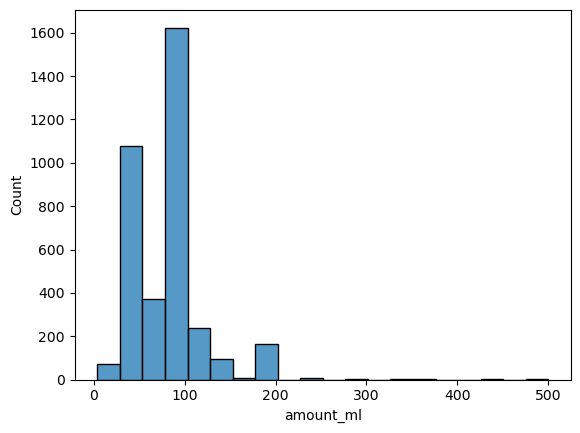

In [25]:
sns.histplot(data=perfumes, x="amount_ml",bins=20)

<Axes: xlabel='price_£', ylabel='Count'>

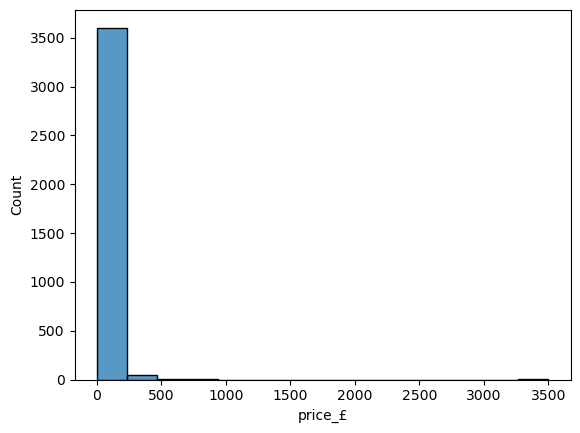

In [29]:
sns.histplot(data=perfumes, x="price_£",bins=15)

In [30]:
perfumes["price_£"].max()

3500.0

In [31]:
#After checking website this perfume retails for £35 not £3500
perfumes[perfumes["price_£"] == 3500]

,name,amount_ml,price_£,review_0-10,cost_per_ml
1992,Moschino Forever for Men,30,3500.0,7.6,116.666667


In [37]:
#changing price value for row 1992 from 3500 to 35
perfumes.at[1992, "price_£"] = 35

In [38]:
perfumes.iloc[1992]


name           Moschino Forever for Men  
amount_ml                              30
price_£                              35.0
review_0-10                           7.6
cost_per_ml                    116.666667
Name: 1992, dtype: object

<Axes: xlabel='price_£', ylabel='Count'>

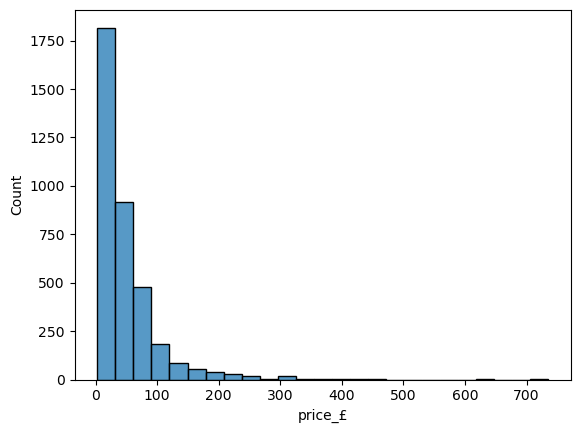

In [45]:
sns.histplot(data=perfumes, x="price_£",bins=25)

In [46]:
perfumes["price_£"].max()

734.99

In [47]:
perfumes[perfumes["price_£"] == 734.99]

,name,amount_ml,price_£,review_0-10,cost_per_ml
1068,Giorgio Armani Code Profumo,200,734.99,7.8,3.67495


In [48]:
perfumes.at[1068, "price_£"] = 90

In [49]:
perfumes["price_£"].max()

645.47

In [51]:
perfumes[perfumes["price_£"] == 645.47]

,name,amount_ml,price_£,review_0-10,cost_per_ml
3503,Creed Tabarome Millesime,500,645.47,7.2,1.29094


<Axes: xlabel='price_£', ylabel='Count'>

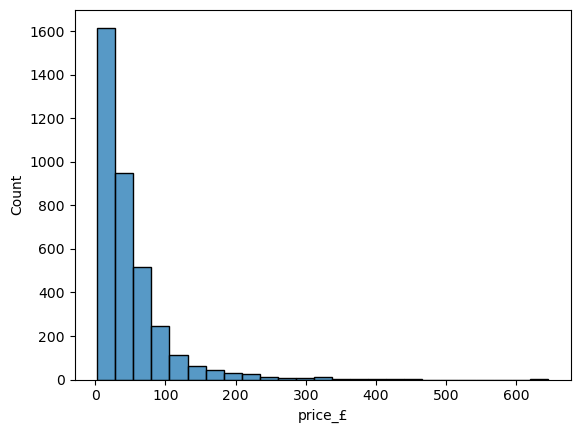

In [52]:
sns.histplot(data=perfumes, x="price_£",bins=25)

<Axes: xlabel='review_0-10', ylabel='Count'>

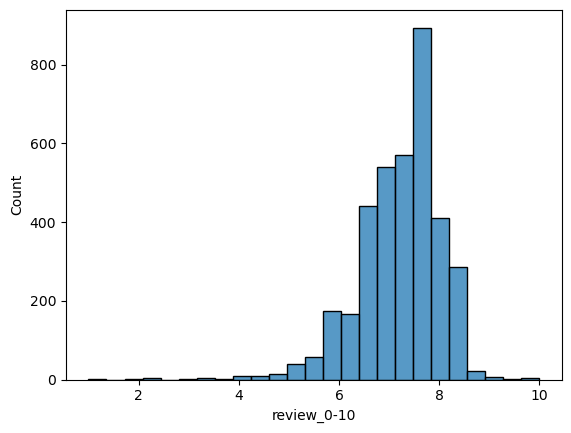

In [54]:
sns.histplot(data=perfumes, x="review_0-10",bins=25)

In [55]:
perfumes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3658 entries, 0 to 3657
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         3658 non-null   object 
 1   amount_ml    3658 non-null   int64  
 2   price_£      3658 non-null   float64
 3   review_0-10  3658 non-null   float64
 4   cost_per_ml  3658 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 300.5+ KB


In [56]:
perfumes.to_csv("perfume_fini.csv")

In [17]:
#finding the cheapest perfumes with a review score of at least 8
perfumes[perfumes["review_0-10"] >=8].sort_values("cost_per_ml").head(10)

,name,amount_ml,price_£,review_0-10,cost_per_ml
2976,Revolution Man Limitless Noir,100,5.99,8.1,0.059900
2463,Dana Mandate,100,5.99,8.1,0.059900
2534,Calvin Klein Eternity Aqua Body Spray for Men,160,10.93,10.0,0.068312
1572,Revolution Man Transcendent,100,6.87,8.7,0.068700
2400,Revolution Man Resurrection,100,6.87,8.5,0.068700
1954,Revolution Man Carbon Pulse,100,6.87,8.6,0.068700
1154,Cuba Royal Fortune,100,8.40,8.0,0.084000
609,Police Wild Night,100,8.70,8.0,0.087000
3208,Jeanne Arthes Sultane Men Oud,100,8.85,8.3,0.088500
3381,Jeanne Arthes Night Club,100,8.90,8.2,0.089000


In [18]:
#Finding the highest reviewed perfumes for the lowest cost 
perfumes.sort_values(["review_0-10", "cost_per_ml"], ascending=[False,True]).head(10)

,name,amount_ml,price_£,review_0-10,cost_per_ml
2534,Calvin Klein Eternity Aqua Body Spray for Men,160,10.93,10.0,0.068312
3270,Emper Saga,100,12.80,10.0,0.128000
1003,Milano Man,50,6.95,10.0,0.139000
1254,Khadlaj Oud pour Noble,100,22.00,10.0,0.220000
2613,La Fede Intoxicate Blue Elixir,100,24.99,9.6,0.249900
2779,Grandeur L'Ambre,100,38.99,9.1,0.389900
3344,Bentley Beyond The Collection Magnetic Amber,100,94.35,9.1,0.943500
1807,Emper Protocol,100,13.60,9.0,0.136000
1799,Police Royal Black,100,21.99,9.0,0.219900
3379,Louis Cardin D'noire,85,21.86,9.0,0.257176


In [19]:
#finding the best reviewed perfume for less than £50
perfumes[perfumes["price_£"] <= 50].sort_values("review_0-10", ascending=False).head(10)

,name,amount_ml,price_£,review_0-10,cost_per_ml
2534,Calvin Klein Eternity Aqua Body Spray for Men,160,10.93,10.0,0.068312
1254,Khadlaj Oud pour Noble,100,22.00,10.0,0.220000
1003,Milano Man,50,6.95,10.0,0.139000
3270,Emper Saga,100,12.80,10.0,0.128000
2613,La Fede Intoxicate Blue Elixir,100,24.99,9.6,0.249900
2779,Grandeur L'Ambre,100,38.99,9.1,0.389900
1799,Police Royal Black,100,21.99,9.0,0.219900
2065,Hugo Boss Bottled Collector's Edition,50,36.40,9.0,0.728000
1807,Emper Protocol,100,13.60,9.0,0.136000
2849,Franck Olivier Bamboo America,75,20.77,9.0,0.276933


In [20]:
#does cost_per_ml corrolate with review score 
perfumes[["review_0-10", "cost_per_ml"]].corr()

,review_0-10,cost_per_ml
review_0-10,1.000000,0.081522
cost_per_ml,0.081522,1.000000


(0.0, 20.0)

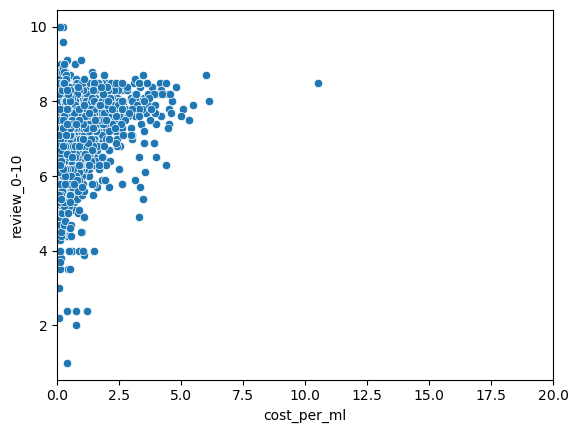

In [21]:
#cost_per_ml plotted against review score
fig, ax = plt.subplots()
sns.scatterplot(data=perfumes, x="cost_per_ml", y="review_0-10")
ax.set_xlim(0, 20) 